# Notebook to visualize linear regression

It will show it fitting to the dataset overtime

In [547]:
from sigil.linear import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [548]:
# number of points
n = 100
x1 = np.random.rand(n) * 50
x2 = np.random.rand(n) * 20
# 2d feature matrix
X = np.column_stack((x1, x2))

# create a true underlying model with some linear relationship
# (y = 10x1 + 5x2 + 30)
y = (10 * x1) + (5 * x2) + 30

# shape them as pairs
print(X[:5])
print(y[:5])

[[14.27610617  8.00362387]
 [32.84081143 15.0013615 ]
 [18.25515339 15.29336281]
 [36.52075248  6.16763629]
 [37.01702037 19.68755924]]
[212.77918101 433.41492183 289.01834791 426.04570623 498.60799991]


The linear model underneath is $y = 10x + 5x + 30$, so we will generate some random $x$ values, get the correct $y$ output, predict on $x$ and compare the difference.

In [549]:
test_samples = 50000
x1_test = np.linspace(0, 50, test_samples)
x2_test = np.linspace(0, 20, test_samples)
X_test = np.column_stack((x1_test, x2_test))
y_test = (10 * x1_test) + (5 * x2_test) + 30

In [550]:
model = LinearRegression(learning_rate=0.0005, n_iterations=20000)
model.fit(X, y)
print(f"Weights: {model.weights}")
print(f"Bias: {model.bias}")

Weights: [10.04746115  5.12394605]
Bias: 27.067380995001148


In [551]:
predicted = model.predict(X_test)
errors = predicted - y_test
abs_errors = np.abs(errors)
mean_absolute_error = np.mean(abs_errors)
print(f"MAE: {mean_absolute_error}")

MAE: 1.2659186261080488


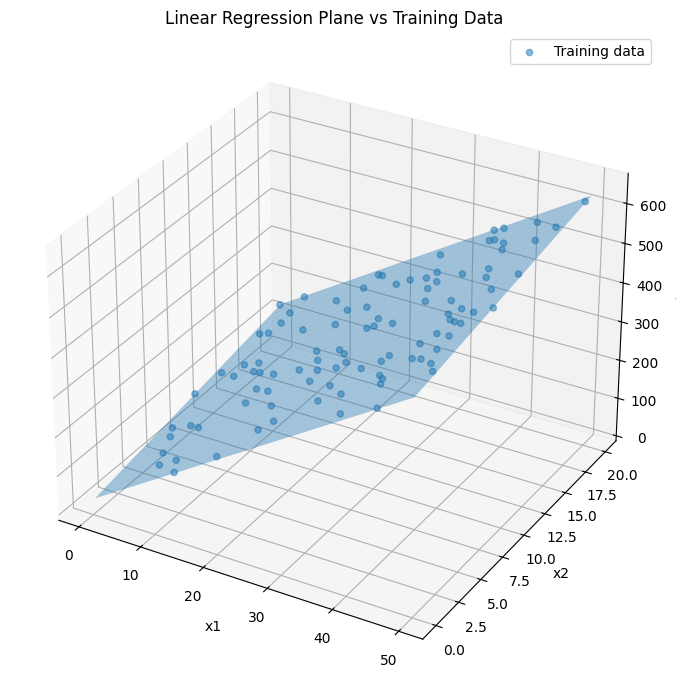

In [560]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")

# zs is somehow default to an integer in mplot3d, so we need to ignore type checking here
ax.scatter(x1, x2, y, alpha=0.5, label="Training data") # type: ignore

# create a grid over x1, x2 to draw the regression plane
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30),
)

X_grid = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
y_grid = model.predict(X_grid).reshape(x1_grid.shape)

# plot the learned plane
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.4)

ax.set_title("Linear Regression Plane vs Training Data")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.legend()

plt.tight_layout()
plt.show()